# 0. Station Information
* Station Name: REDE_FOREST BRIDGE_E_202501
* Water Quality Data Link: https://environment.data.gov.uk/hydrology/station/E95999A

## 0. Import the Relevant Libraries

In [ ]:
# Import the relevant libraries
import pandas as pd
import numpy as np
import urllib.request
from pathlib import Path
import io
from sklearn.preprocessing import MinMaxScaler
import torch
import matplotlib.pyplot as plt

## 1. Import Base Classes and Helper Functions from the Project GitHub and Set Random Seeds

In [ ]:
# Import the Base Classes and Helper Functions from the Project GitHub
url = "https://raw.githubusercontent.com/VinceMoran/EA_Water_Quality_Time_Series_Prediction//main/base_classes_and_helper_functions.py"

file_path = Path("base_classes_and_helper_functions.py")
if not file_path.exists():
    urllib.request.urlretrieve(url, file_path)
import base_classes_and_helper_functions as bchf

In [ ]:
# Set the random seed for all PRNGs to ensure reproducibility
bchf.set_random_seed()

## 2. Load the Raw Data from the Project GitHub into a Pandas DataFrame

In [ ]:
# Create the path to the directory containing the data in the Jupyter notebook environment
data_path = bchf.load_raw_data(url="https://github.com/VinceMoran/EA_Water_Quality_Time_Series_Prediction/raw/main/data/processed_data/river_rede/REDE_FOREST_BRIDGE_E_202501/df_parameters_preprocessed.zip")

# Assign the full filepath for the preprocessed data
parameter_path = "/content" / data_path / "df_parameters_preprocessed.csv"

[INFO] data/raw_data directory has been created.
[INFO] Downloading data...
[INFO] Data extracted to data/raw_data.
[INFO] ZIP file removed.


In [ ]:
# Load the data into a Pandas DataFrame
df_parameters = pd.read_csv(parameter_path)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,dateTime,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,temperature_impossible,turbidity_impossible,ammonium_anomaly,conductivity_anomaly,oxygen_perc_anomaly,turbidity_anomaly,oxygen_conc_anomaly,temperature_anomaly
0,2025-01-10 09:50:55,NaN,NaN,9.61,101.73,18.106,44.33,True,True,False,False,False,False,False,False,False,False,False,False
1,2025-01-10 09:51:23,NaN,NaN,9.60,101.65,18.129,44.07,True,True,False,False,False,False,False,False,False,False,False,False
2,2025-01-10 09:51:51,NaN,NaN,9.62,101.94,18.153,44.05,True,True,False,False,False,False,False,False,False,False,False,False
3,2025-01-10 09:52:19,NaN,NaN,9.60,101.79,18.177,43.89,True,True,False,False,False,False,False,False,False,False,False,False
4,2025-01-10 09:52:47,NaN,NaN,9.61,101.86,18.199,43.46,True,True,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Investigate the unique value distributions of the DataFrame
bchf.unique_value_counts(df_parameters, "WATER QUALITY PARAMETER DATAFRAME")

DISTINCT VALUE COUNTS FOR WATER QUALITY PARAMETER DATAFRAME:
Variable         Number of Distinct Value Counts
dateTime                   13984          

ammonium                    200           

conductivity               8937           

oxygen_conc                 660           

oxygen_perc                3804           

temperature                9291           

turbidity                  1966           

ammonium_impossible             2            

conductivity_impossible             2            

oxygen_conc_impossible             2            

oxygen_perc_impossible             2            

temperature_impossible             2            

turbidity_impossible             2            

ammonium_anomaly             2            

conductivity_anomaly             2            

oxygen_perc_anomaly             2            

turbidity_anomaly             2            

oxygen_conc_anomaly             1            

temperature_anomaly             1            



In [ ]:
# Investigate the datatypes and numbers of missing values for each variable
bchf.datatypes_and_missing_values(df_parameters, "WATER QUALITY PARAMETER DATAFRAME")

DATATYPES AND MISSING VALUES FOR WATER QUALITY PARAMETER DATAFRAME
Variable           Data Type      Number of Missing Values
dateTime          , object        ,            0            
ammonium          , float64       ,            13           
conductivity      , float64       ,            13           
oxygen_conc       , float64       ,            0            
oxygen_perc       , float64       ,            0            
temperature       , float64       ,            0            
turbidity         , float64       ,            0            
ammonium_impossible, bool          ,            0            
conductivity_impossible, bool          ,            0            
oxygen_conc_impossible, bool          ,            0            
oxygen_perc_impossible, bool          ,            0            
temperature_impossible, bool          ,            0            
turbidity_impossible, bool          ,            0            
ammonium_anomaly  , bool          ,            0            


## 3. Reindex the DataFrame and Engineer Additional Features for Time Series Modelling

In [ ]:
# Change the data type for the dateTime column to datetime64
df_parameters["dateTime"] = pd.to_datetime(df_parameters["dateTime"], dayfirst=False)

# Set the datetime column as the index
df_parameters.set_index('dateTime', inplace=True)

# Investigate the first 5 rows of the reindexed DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,temperature_impossible,turbidity_impossible,ammonium_anomaly,conductivity_anomaly,oxygen_perc_anomaly,turbidity_anomaly,oxygen_conc_anomaly,temperature_anomaly
dateTime,,,,,,,,,,,,,,,,,,
2025-01-10 09:50:55,NaN,NaN,9.61,101.73,18.106,44.33,True,True,False,False,False,False,False,False,False,False,False,False
2025-01-10 09:51:23,NaN,NaN,9.60,101.65,18.129,44.07,True,True,False,False,False,False,False,False,False,False,False,False
2025-01-10 09:51:51,NaN,NaN,9.62,101.94,18.153,44.05,True,True,False,False,False,False,False,False,False,False,False,False
2025-01-10 09:52:19,NaN,NaN,9.60,101.79,18.177,43.89,True,True,False,False,False,False,False,False,False,False,False,False
2025-01-10 09:52:47,NaN,NaN,9.61,101.86,18.199,43.46,True,True,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Numerically encode date and time as features
df_parameters["day_of_year"] = df_parameters.index.dayofyear
df_parameters["day_of_year_sin"] = np.sin(2*np.pi*(df_parameters["day_of_year"]/365))
df_parameters["day_of_year_cos"] = np.cos(2*np.pi*(df_parameters["day_of_year"]/365))

df_parameters["minute_of_day"] = df_parameters.index.hour*60 + df_parameters.index.minute
df_parameters["minute_of_day_sin"] = np.sin(2*np.pi*(df_parameters["minute_of_day"]/1440))
df_parameters["minute_of_day_cos"] = np.cos(2*np.pi*(df_parameters["minute_of_day"]/1440))

# Remove redundant columns
df_parameters.drop(["day_of_year", "minute_of_day"], axis=1, inplace=True)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,ammonium_anomaly,conductivity_anomaly,oxygen_perc_anomaly,turbidity_anomaly,oxygen_conc_anomaly,temperature_anomaly,day_of_year_sin,day_of_year_cos,minute_of_day_sin,minute_of_day_cos
dateTime,,,,,,,,,,,,,,,,,,,,,
2025-01-10 09:50:55,NaN,NaN,9.61,101.73,18.106,44.33,True,True,False,False,...,False,False,False,False,False,False,0.171293,0.98522,0.537300,-0.843391
2025-01-10 09:51:23,NaN,NaN,9.60,101.65,18.129,44.07,True,True,False,False,...,False,False,False,False,False,False,0.171293,0.98522,0.533615,-0.845728
2025-01-10 09:51:51,NaN,NaN,9.62,101.94,18.153,44.05,True,True,False,False,...,False,False,False,False,False,False,0.171293,0.98522,0.533615,-0.845728
2025-01-10 09:52:19,NaN,NaN,9.60,101.79,18.177,43.89,True,True,False,False,...,False,False,False,False,False,False,0.171293,0.98522,0.529919,-0.848048
2025-01-10 09:52:47,NaN,NaN,9.61,101.86,18.199,43.46,True,True,False,False,...,False,False,False,False,False,False,0.171293,0.98522,0.529919,-0.848048


In [ ]:
# Create lagged variables for each feature
variables = ["ammonium", "conductivity", "oxygen_conc", "oxygen_perc", "temperature", "turbidity"]

for i in np.arange(1, 5):
  for variable in variables:
    df_parameters[f"{variable}_lag{i}"] = df_parameters[variable].shift(periods=i)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,oxygen_conc_lag3,oxygen_perc_lag3,temperature_lag3,turbidity_lag3,ammonium_lag4,conductivity_lag4,oxygen_conc_lag4,oxygen_perc_lag4,temperature_lag4,turbidity_lag4
dateTime,,,,,,,,,,,,,,,,,,,,,
2025-01-10 09:50:55,NaN,NaN,9.61,101.73,18.106,44.33,True,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-10 09:51:23,NaN,NaN,9.60,101.65,18.129,44.07,True,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-10 09:51:51,NaN,NaN,9.62,101.94,18.153,44.05,True,True,False,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-10 09:52:19,NaN,NaN,9.60,101.79,18.177,43.89,True,True,False,False,...,9.61,101.73,18.106,44.33,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-10 09:52:47,NaN,NaN,9.61,101.86,18.199,43.46,True,True,False,False,...,9.60,101.65,18.129,44.07,NaN,NaN,9.61,101.73,18.106,44.33


In [ ]:
# Create moving averages for each water quality variable
moving_average_windows = np.array([6, 12, 24]) # hours
timestep_windows = moving_average_windows * 4 # number of timesteps

# Loop through creating moving averages from only past values to avoid temporal leakage
for i in timestep_windows:
  for variable in variables:
    df_parameters[f"{variable}_ma{i}"] = df_parameters[variable].rolling(window=i, min_periods=1).mean()

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,oxygen_conc_ma48,oxygen_perc_ma48,temperature_ma48,turbidity_ma48,ammonium_ma96,conductivity_ma96,oxygen_conc_ma96,oxygen_perc_ma96,temperature_ma96,turbidity_ma96
dateTime,,,,,,,,,,,,,,,,,,,,,
2025-01-10 09:50:55,NaN,NaN,9.61,101.73,18.106,44.33,True,True,False,False,...,9.6100,101.730000,18.106000,44.330,NaN,NaN,9.6100,101.730000,18.106000,44.330
2025-01-10 09:51:23,NaN,NaN,9.60,101.65,18.129,44.07,True,True,False,False,...,9.6050,101.690000,18.117500,44.200,NaN,NaN,9.6050,101.690000,18.117500,44.200
2025-01-10 09:51:51,NaN,NaN,9.62,101.94,18.153,44.05,True,True,False,False,...,9.6100,101.773333,18.129333,44.150,NaN,NaN,9.6100,101.773333,18.129333,44.150
2025-01-10 09:52:19,NaN,NaN,9.60,101.79,18.177,43.89,True,True,False,False,...,9.6075,101.777500,18.141250,44.085,NaN,NaN,9.6075,101.777500,18.141250,44.085
2025-01-10 09:52:47,NaN,NaN,9.61,101.86,18.199,43.46,True,True,False,False,...,9.6080,101.794000,18.152800,43.960,NaN,NaN,9.6080,101.794000,18.152800,43.960


In [ ]:
# Create seasonal lagged features
seasonality = 96 # 24 hours prior in 15 minute sensor data

target_vars = ["ammonium", "oxygen_conc", "temperature"]

for target in target_vars:
  df_parameters[f"{target}_seasonal_lag{seasonality}"] = df_parameters[target].shift(periods=seasonality)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,turbidity_ma48,ammonium_ma96,conductivity_ma96,oxygen_conc_ma96,oxygen_perc_ma96,temperature_ma96,turbidity_ma96,ammonium_seasonal_lag96,oxygen_conc_seasonal_lag96,temperature_seasonal_lag96
dateTime,,,,,,,,,,,,,,,,,,,,,
2025-01-10 09:50:55,NaN,NaN,9.61,101.73,18.106,44.33,True,True,False,False,...,44.330,NaN,NaN,9.6100,101.730000,18.106000,44.330,NaN,NaN,NaN
2025-01-10 09:51:23,NaN,NaN,9.60,101.65,18.129,44.07,True,True,False,False,...,44.200,NaN,NaN,9.6050,101.690000,18.117500,44.200,NaN,NaN,NaN
2025-01-10 09:51:51,NaN,NaN,9.62,101.94,18.153,44.05,True,True,False,False,...,44.150,NaN,NaN,9.6100,101.773333,18.129333,44.150,NaN,NaN,NaN
2025-01-10 09:52:19,NaN,NaN,9.60,101.79,18.177,43.89,True,True,False,False,...,44.085,NaN,NaN,9.6075,101.777500,18.141250,44.085,NaN,NaN,NaN
2025-01-10 09:52:47,NaN,NaN,9.61,101.86,18.199,43.46,True,True,False,False,...,43.960,NaN,NaN,9.6080,101.794000,18.152800,43.960,NaN,NaN,NaN


In [ ]:
# Loop through creating moving averages of imputed value counts from only past values to avoid temporal leakage
for i in timestep_windows:
  for variable in variables:
    df_parameters[f"{variable}_imputed_count_{i}"] = (df_parameters[f"{variable}_impossible"] + df_parameters[f"{variable}_anomaly"]).rolling(window=i, min_periods=1).sum()

# Inpect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,oxygen_conc_imputed_count_48,oxygen_perc_imputed_count_48,temperature_imputed_count_48,turbidity_imputed_count_48,ammonium_imputed_count_96,conductivity_imputed_count_96,oxygen_conc_imputed_count_96,oxygen_perc_imputed_count_96,temperature_imputed_count_96,turbidity_imputed_count_96
dateTime,,,,,,,,,,,,,,,,,,,,,
2025-01-10 09:50:55,NaN,NaN,9.61,101.73,18.106,44.33,True,True,False,False,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2025-01-10 09:51:23,NaN,NaN,9.60,101.65,18.129,44.07,True,True,False,False,...,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0
2025-01-10 09:51:51,NaN,NaN,9.62,101.94,18.153,44.05,True,True,False,False,...,0.0,0.0,0.0,0.0,3.0,3.0,0.0,0.0,0.0,0.0
2025-01-10 09:52:19,NaN,NaN,9.60,101.79,18.177,43.89,True,True,False,False,...,0.0,0.0,0.0,0.0,4.0,4.0,0.0,0.0,0.0,0.0
2025-01-10 09:52:47,NaN,NaN,9.61,101.86,18.199,43.46,True,True,False,False,...,0.0,0.0,0.0,0.0,5.0,5.0,0.0,0.0,0.0,0.0


## 4. Create Target Variables for Time Series Prediction

In [ ]:
# Create the target variables
timesteps = [1, 2, 4, 24, 48, 96]
for target in target_vars:
    for timestep in timesteps:
        df_parameters[f"{target}_target_t_{str(timestep)}"] = df_parameters[target].shift(periods=-timestep)

# Removed NaN rows added after shifting features and targets
df_parameters.dropna(inplace=True)

# Inspect the first 5 rows of the DataFrame
df_parameters.head()

,ammonium,conductivity,oxygen_conc,oxygen_perc,temperature,turbidity,ammonium_impossible,conductivity_impossible,oxygen_conc_impossible,oxygen_perc_impossible,...,oxygen_conc_target_t_4,oxygen_conc_target_t_24,oxygen_conc_target_t_48,oxygen_conc_target_t_96,temperature_target_t_1,temperature_target_t_2,temperature_target_t_4,temperature_target_t_24,temperature_target_t_48,temperature_target_t_96
dateTime,,,,,,,,,,,,,,,,,,,,,
2025-01-31 05:01:16,0.15,178.80,13.66,100.7800,2.725,1.64,False,False,False,False,...,13.71,13.48,13.34,12.49,2.780,2.817,2.769,3.478,3.440,5.667
2025-01-31 06:01:16,0.15,179.97,13.64,100.8100,2.780,1.57,False,False,False,False,...,13.88,13.48,13.36,12.48,2.817,2.816,2.823,3.465,3.378,5.661
2025-01-31 07:01:16,0.15,181.47,13.64,100.8600,2.817,1.50,False,False,False,False,...,14.00,13.48,13.38,12.48,2.816,2.769,2.979,3.455,3.331,5.664
2025-01-31 08:01:16,0.16,185.38,13.63,100.8200,2.816,1.52,False,False,False,False,...,14.06,13.49,13.41,12.48,2.769,2.823,3.185,3.450,3.276,5.675
2025-01-31 09:01:16,0.16,188.06,13.71,101.8625,2.769,1.47,False,False,False,False,...,14.06,13.58,13.53,12.57,2.823,2.979,3.385,3.450,3.273,5.725


## 4. Split Dataset Into Training/Validation/Testing Sets and Normalise Features

In [ ]:
# Split the DataFrame into training, validation, and testing sets
df_train, df_val, df_test = bchf.train_val_test_split(df_parameters,
                                                      train_size=0.6,
                                                      val_size=0.2,
                                                      test_size=0.2)

In [ ]:
# Initialise the scaler using min-max normalisation (avoid temporal leakage by splitting into training, validation, and testing before fitting the scaler)
feature_scaler = MinMaxScaler()

# Create copies of the DataFrames for scaling
df_train_scaled, df_val_scaled, df_test_scaled = df_train.copy(), df_val.copy(), df_test.copy()

# Create a list of target variables
target_vars = ["ammonium", "oxygen_conc", "temperature"]

# Create a list of features for scaling
features_to_scale = df_train.columns

# Drop anomaly and impossible flags from the features to be scaled list using loop
var_sub_names = ["ammonium", "conductivity", "oxygen_conc", "oxygen_perc", "temperature", "turbidity"]
for var in var_sub_names:
  features_to_scale = features_to_scale.drop(f"{var}_impossible")
  features_to_scale = features_to_scale.drop(f"{var}_anomaly")

# Drop temporal features from the list of features to be scaled
features_to_scale = features_to_scale.drop("day_of_year_sin")
features_to_scale = features_to_scale.drop("day_of_year_cos")
features_to_scale = features_to_scale.drop("minute_of_day_sin")
features_to_scale = features_to_scale.drop("minute_of_day_cos")

# Remove targets from the list of features for scaling
for target in target_vars:
    for timestep in timesteps:
      features_to_scale = features_to_scale.drop(f"{target}_target_t_{timestep}")

print(features_to_scale)

Index(['ammonium', 'conductivity', 'oxygen_conc', 'oxygen_perc', 'temperature',
       'turbidity', 'ammonium_lag1', 'conductivity_lag1', 'oxygen_conc_lag1',
       'oxygen_perc_lag1', 'temperature_lag1', 'turbidity_lag1',
       'ammonium_lag2', 'conductivity_lag2', 'oxygen_conc_lag2',
       'oxygen_perc_lag2', 'temperature_lag2', 'turbidity_lag2',
       'ammonium_lag3', 'conductivity_lag3', 'oxygen_conc_lag3',
       'oxygen_perc_lag3', 'temperature_lag3', 'turbidity_lag3',
       'ammonium_lag4', 'conductivity_lag4', 'oxygen_conc_lag4',
       'oxygen_perc_lag4', 'temperature_lag4', 'turbidity_lag4',
       'ammonium_ma24', 'conductivity_ma24', 'oxygen_conc_ma24',
       'oxygen_perc_ma24', 'temperature_ma24', 'turbidity_ma24',
       'ammonium_ma48', 'conductivity_ma48', 'oxygen_conc_ma48',
       'oxygen_perc_ma48', 'temperature_ma48', 'turbidity_ma48',
       'ammonium_ma96', 'conductivity_ma96', 'oxygen_conc_ma96',
       'oxygen_perc_ma96', 'temperature_ma96', 'turbidity_ma96

In [ ]:
# Fit the scaler to the features during training
feature_scaler.fit(df_train_scaled[features_to_scale])

# Transform the features using min-max normalisation
df_train_scaled[features_to_scale] = feature_scaler.transform(df_train_scaled[features_to_scale])
df_val_scaled[features_to_scale] = feature_scaler.transform(df_val_scaled[features_to_scale])
df_test_scaled[features_to_scale] = feature_scaler.transform(df_test_scaled[features_to_scale])

In [ ]:
# Change data types to float32 and int8 to reduce memory and speed up training
float_cols = df_train_scaled.select_dtypes(include='float64').columns # identify column names containing 64 bit floating point data
bool_cols = df_train_scaled.select_dtypes(include='bool').columns # identify column names containing Boolean data

# Loop through DataFrames to convert columns to appropriate data types
for df in [df_train_scaled, df_val_scaled, df_test_scaled]:
  df[float_cols] = df[float_cols].astype('float32')
  df[bool_cols] = df[bool_cols].astype('int8')

In [ ]:
# Investigate the datatype and number of missing values for each variable after preparing dataset for modelling
bchf.datatypes_and_missing_values(df_train_scaled, "WATER QUALITY PARAMETER DATAFRAME")

DATATYPES AND MISSING VALUES FOR WATER QUALITY PARAMETER DATAFRAME
Variable           Data Type      Number of Missing Values
ammonium          , float32       ,            0            
conductivity      , float32       ,            0            
oxygen_conc       , float32       ,            0            
oxygen_perc       , float32       ,            0            
temperature       , float32       ,            0            
turbidity         , float32       ,            0            
ammonium_impossible, int8          ,            0            
conductivity_impossible, int8          ,            0            
oxygen_conc_impossible, int8          ,            0            
oxygen_perc_impossible, int8          ,            0            
temperature_impossible, int8          ,            0            
turbidity_impossible, int8          ,            0            
ammonium_anomaly  , int8          ,            0            
conductivity_anomaly, int8          ,            0           

## 6. Scale Target Data and Prepare Tensors and DataLoaders for Modelling

In [ ]:
# Create list of target variables
targets = []
for target in target_vars:
    for timestep in timesteps:
        targets.append(f"{target}_target_t_{str(timestep)}")

# Create list of features
features = df_train_scaled.columns.drop(targets)

print("Targets:", targets)
print("\nFeatures:", features)

Targets: ['ammonium_target_t_1', 'ammonium_target_t_2', 'ammonium_target_t_4', 'ammonium_target_t_24', 'ammonium_target_t_48', 'ammonium_target_t_96', 'oxygen_conc_target_t_1', 'oxygen_conc_target_t_2', 'oxygen_conc_target_t_4', 'oxygen_conc_target_t_24', 'oxygen_conc_target_t_48', 'oxygen_conc_target_t_96', 'temperature_target_t_1', 'temperature_target_t_2', 'temperature_target_t_4', 'temperature_target_t_24', 'temperature_target_t_48', 'temperature_target_t_96']

Features: Index(['ammonium', 'conductivity', 'oxygen_conc', 'oxygen_perc', 'temperature',
       'turbidity', 'ammonium_impossible', 'conductivity_impossible',
       'oxygen_conc_impossible', 'oxygen_perc_impossible',
       'temperature_impossible', 'turbidity_impossible', 'ammonium_anomaly',
       'conductivity_anomaly', 'oxygen_perc_anomaly', 'turbidity_anomaly',
       'oxygen_conc_anomaly', 'temperature_anomaly', 'day_of_year_sin',
       'day_of_year_cos', 'minute_of_day_sin', 'minute_of_day_cos',
       'ammonium_la

In [ ]:
# Create array for training features
X_train = df_train_scaled[features].values
# Create training targets dictionary
y_train_dict = {}
# Populate training targets dictionary with training data
for target in targets:
    key = target
    value = df_train_scaled[target].values
    y_train_dict[key] = value

# Create array for validation features
X_val = df_val_scaled[features].values
# Create validation targets dictionary
y_val_dict = {}
# Populate validation targets dictionary with validation data
for target in targets:
    key = target
    value = df_val_scaled[target].values
    y_val_dict[key] = value

# Create array for testing features
X_test = df_test_scaled[features].values
# Create testing targets dictionary
y_test_dict = {}
# Populate testing targets dictionary with testing data
for target in targets:
    key = target
    value = df_test_scaled[target].values
    y_test_dict[key] = value

In [ ]:
# Create dictionaries for scaling targets
target_scaler_dict = {} # dictionary for storing scaler objects
y_train_scaled_dict = {} # dictionary for storing scaled training targets
y_val_scaled_dict = {} # dictionary for storing scaled validation targets
y_test_scaled_dict = {} # dictionary for storing scaled testing targets

# Scale the targets
for target in targets:
    # Instantiate the scaler object
    scaler = MinMaxScaler()
    # Obtain the training targets
    y_train = df_train_scaled[target].values.reshape(-1, 1)
    # Fit the scaler to the training data targets
    scaler.fit(y_train)
    # Scale training data targets and store in dictionary
    y_train_scaled_dict[target] = scaler.transform(y_train)
    # Scale the validation data targets and store in dictionary
    y_val_scaled_dict[target] = scaler.transform(df_val_scaled[target].values.reshape(-1, 1))
    # Scale the testing data targets and store in dictionary
    y_test_scaled_dict[target] = scaler.transform(df_test_scaled[target].values.reshape(-1, 1))
    # Store the fitted scaler in the scaler dictionary
    target_scaler_dict[target] = scaler

In [ ]:
# Create dictionary for holding DataLoader objects for each target
dataloader_dict = {}

# Populate the DataLoader object for each target variable
for target in targets:
    dataloader_dict[target] = bchf.TimeSeries(
        batch_size=32, # minibatch size defaults to 32 to balance convergence speed with gradient estimation accuracy
        num_steps=96, # sliding window of 96 represents 24hrs of 15 minute resolution data
        X_train=X_train,
        y_train=y_train_scaled_dict[target],
        X_val=X_val,
        y_val=y_val_scaled_dict[target],
        X_test=X_test,
        y_test=y_test_scaled_dict[target]
    )

##7. Download Hyperparameter Optimisation (HPO) Results from the Project GitHub

In [ ]:
# Create the path to the directory containing the data in the Jupyter notebook environment
hpo_ammonium_results_path = bchf.load_raw_data(url="https://raw.githubusercontent.com/VinceMoran/EA_Water_Quality_Time_Series_Prediction/main/models/lstm/hpo/results/river_rede/REDE_FOREST_BRIDGE_E_202501/REDE_FOREST%20BRIDGE_E_202501_ammonium_HPO_results.zip")
hpo_oxygen_results_path = bchf.load_raw_data(url="https://raw.githubusercontent.com/VinceMoran/EA_Water_Quality_Time_Series_Prediction/main/models/lstm/hpo/results/river_rede/REDE_FOREST_BRIDGE_E_202501/REDE_FOREST%20BRIDGE_E_202501_oxygen_HPO_results.zip")
hpo_temperature_results_path = bchf.load_raw_data(url="https://raw.githubusercontent.com/VinceMoran/EA_Water_Quality_Time_Series_Prediction/main/models/lstm/hpo/results/river_rede/REDE_FOREST_BRIDGE_E_202501/REDE_FOREST%20BRIDGE_E_202501_temperature_HPO_results.zip")

# Assign the full filepath for the preprocessed data
hpo_ammonium_results_path = "/content" / hpo_ammonium_results_path / "REDE_FOREST BRIDGE_E_202501_ammonium_HPO_results.csv"
hpo_oxygen_results_path = "/content"/ hpo_oxygen_results_path / "REDE_FOREST BRIDGE_E_202501_oxygen_HPO_results.csv"
hpo_temperature_results_path = "/content" / hpo_temperature_results_path / "REDE_FOREST BRIDGE_E_202501_temperature_HPO_results.csv"

[INFO] data/raw_data directory already exists.
[INFO] Downloading data...
[INFO] Data extracted to data/raw_data.
[INFO] ZIP file removed.
[INFO] data/raw_data directory already exists.
[INFO] Downloading data...
[INFO] Data extracted to data/raw_data.
[INFO] ZIP file removed.
[INFO] data/raw_data directory already exists.
[INFO] Downloading data...
[INFO] Data extracted to data/raw_data.
[INFO] ZIP file removed.


In [ ]:
# Load the HPO results into a Pandas DataFrame
df_hpo_ammonium_results = pd.read_csv(hpo_ammonium_results_path)
df_hpo_oxygen_results = pd.read_csv(hpo_oxygen_results_path)
df_hpo_temperature_results = pd.read_csv(hpo_temperature_results_path)

# Inspect the first 5 rows of the HPO results DataFrame
#df_hpo_ammonium_results.head()
#df_hpo_oxygen_results.head()
df_hpo_temperature_results.head()

,Unnamed: 0,epoch,validation_error,st_worker_timestamp,st_worker_time,st_worker_iter,st_decision,st_status,trial_id,config_learning_rate,config_num_hiddens,config_num_layers,config_dropout,config_weight_decay,st_tuner_time
0,0,1,0.266342,1.773678e+09,1.334574,0,CONTINUE,InProgress,0,0.00001,64,2,0.2,0.00001,5.002141
1,1,2,0.071900,1.773678e+09,1.853550,1,CONTINUE,InProgress,0,0.00001,64,2,0.2,0.00001,5.002154
2,2,3,0.077024,1.773678e+09,2.361556,2,CONTINUE,InProgress,0,0.00001,64,2,0.2,0.00001,5.002160
3,3,4,0.077878,1.773678e+09,2.873629,3,CONTINUE,InProgress,0,0.00001,64,2,0.2,0.00001,5.002165
4,4,5,0.073862,1.773678e+09,3.391175,4,CONTINUE,Completed,0,0.00001,64,2,0.2,0.00001,10.002747


In [ ]:
# Obtain the index of the row with the minimum validation error
ammonium_min_val_idx = df_hpo_ammonium_results['validation_error'].idxmin()
oxygen_min_val_idx = df_hpo_oxygen_results['validation_error'].idxmin()
temperature_min_val_idx = df_hpo_temperature_results['validation_error'].idxmin()

# Retrieve the row of results with the minimum validation error
ammonium_best_val_row = df_hpo_ammonium_results.loc[ammonium_min_val_idx]
oxygen_best_val_row = df_hpo_oxygen_results.loc[oxygen_min_val_idx]
temperature_best_val_row = df_hpo_temperature_results.loc[temperature_min_val_idx]

# Display the row with minimum validation error
print(f"BEST RESULTS AND HYPERPARAMETERS: \n{ammonium_best_val_row}")
print(f"\n\nBEST RESULTS AND HYPERPARAMETERS: \n{oxygen_best_val_row}")
print(f"\n\nBEST RESULTS AND HYPERPARAMETRS: \n{temperature_best_val_row}")

BEST RESULTS AND HYPERPARAMETERS: 
Unnamed: 0                             45
epoch                                   5
validation_error                 0.039435
st_worker_timestamp     1773677637.306763
st_worker_time                   8.239411
st_worker_iter                          4
st_decision                      CONTINUE
st_status                      InProgress
trial_id                                6
config_learning_rate             0.000112
config_num_hiddens                    256
config_num_layers                       2
config_dropout                   0.331331
config_weight_decay              0.000014
st_tuner_time                   95.173405
Name: 45, dtype: object


BEST RESULTS AND HYPERPARAMETERS: 
Unnamed: 0                            101
epoch                                   7
validation_error                 0.056272
st_worker_timestamp     1773678175.103296
st_worker_time                   5.592979
st_worker_iter                          6
st_decision           

## 8. Train the Model on Ammonium Time Series Data and Save Model Parameters

In [ ]:
# Create a dictionary to hold LSTM models
lstm_model_dict = {}

# Create a mapping of each water quality variable name to the optimised hyperparameter config
hpo_target_mapping = {
    "ammonium": ammonium_best_val_row,
    "oxygen": oxygen_best_val_row,
    "temperature": temperature_best_val_row}

[EarlyStopping] No improvement for 10/10 epochs.
[EarlyStopping] Stopping early at epoch 16. Best val loss: 0.006849


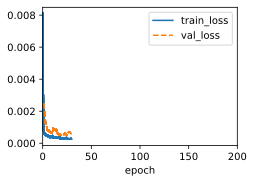

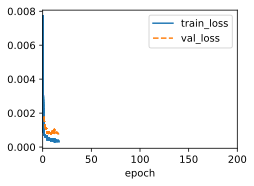

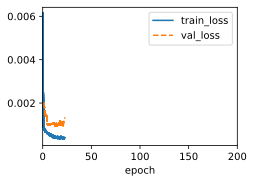

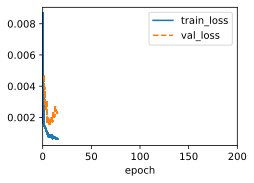

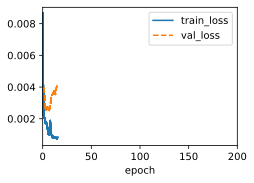

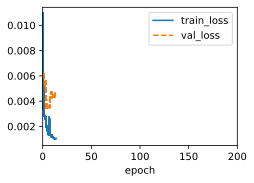

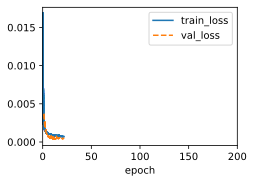

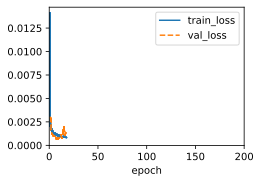

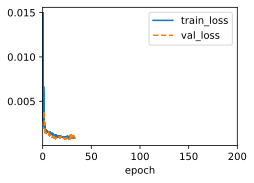

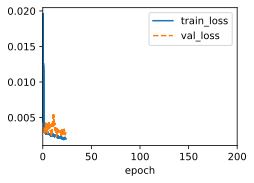

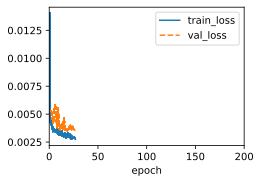

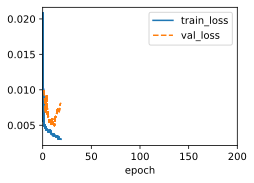

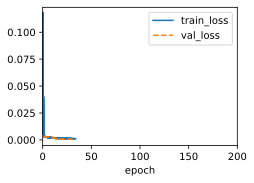

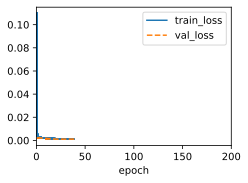

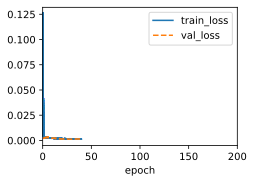

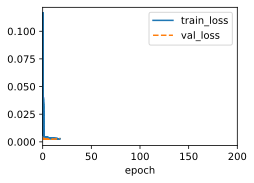

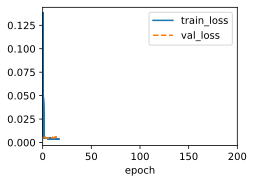

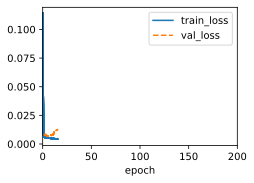

In [ ]:
# Train the LSTM models for each water quality variable and forecast horizon
for target in targets:
    print("\n----------------------------------------------------------------")
    print("----------------------------------------------------------------")
    print("----------------------------------------------------------------")
    print(f"NOW TRAINING TO PREDICT {target}".upper())
    # Obtain the name of the target water quality variable by splitting string on underscores
    var_name = target.split("_")[0] # returns "ammonium", "oxygen", or "temperature"
    # Instantiate the LSTM class with optimised hyperparameters
    lstm = bchf.LSTM(
        num_inputs=X_train.shape[1],
        num_hiddens=int(hpo_target_mapping[var_name]["config_num_hiddens"]), # uses the number of hidden units directly from HPO pipeline
        num_layers=int(hpo_target_mapping[var_name]["config_num_layers"]), # uses the number of layers directly from HPO pipeline
        dropout=float(hpo_target_mapping[var_name]["config_dropout"]) # uses the dropout regularisation rate directly from HPO pipeline
        )
    # Instantiate the model for predicting water quality time series
    lstm_water_quality_model = bchf.RNNWQ(
        rnn=lstm,
        out_features=1, # single-target prediction
        lr=float(hpo_target_mapping[var_name]["config_learning_rate"]), # uses the learning rate directly from HPO pipeline
        weight_decay=float(hpo_target_mapping[var_name]["config_weight_decay"]) # uses the weight decay regularisation rate directly from HPO pipeline
        )
    # Instantiate the trainer for predicting water quality time series
    trainer = bchf.Trainer(max_epochs=200,
                           num_gpus=1,
                           gradient_clip_val=1,
                           early_stopping=True,
                           patience=10,
                           min_delta=0.0,
                           restore_best_params=True)
    # Fit the ammonium model to the time series data
    trainer.fit(lstm_water_quality_model, dataloader_dict[target])
    # Add the trained LSTM water quality model to the dictionary of models
    lstm_model_dict[target] = lstm_water_quality_model

In [ ]:
# Save the state dictionaries of LSTM water quality model parameters
for target in targets:
    torch.save(lstm_model_dict[target].state_dict(), f"{target}_state_dict.pth")